In [1]:
from fed.io import load_data
from fed.eng import clean_data, add_features, combine_dfs
from fed.plot import plot_one_country, plot_all_countries

In [2]:
# Filepaths for data
fp_usd = "data/gdp_ppp_2021_usd.csv"
fp_ppp = "data/gdp_constant_2015_usd.csv"

# Use load function
df_usd = load_data(fp_usd)
display(df_usd.head())

df_ppp = load_data(fp_ppp)
display(df_ppp.head())

,country,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
0,Aruba,ABW,"GDP, PPP (constant 2021 international $)",NY.GDP.MKTP.PP.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,3.916546e+09,4.192605e+09,4.293105e+09,4.197264e+09,3.097085e+09,3.844493e+09,4.171963e+09,4.349844e+09,NaN,NaN
1,Africa Eastern and Southern,AFE,"GDP, PPP (constant 2021 international $)",NY.GDP.MKTP.PP.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,2.539724e+12,2.614938e+12,2.689356e+12,2.753587e+12,2.681304e+12,2.805001e+12,2.908437e+12,2.963096e+12,3.053302e+12,NaN
2,Afghanistan,AFG,"GDP, PPP (constant 2021 international $)",NY.GDP.MKTP.PP.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,1.026717e+11,1.053894e+11,1.066427e+11,1.108141e+11,1.082088e+11,8.576755e+10,8.041550e+10,8.223848e+10,NaN,NaN
3,Africa Western and Central,AFW,"GDP, PPP (constant 2021 international $)",NY.GDP.MKTP.PP.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,2.042058e+12,2.094856e+12,2.159624e+12,2.234492e+12,2.216272e+12,2.306547e+12,2.399962e+12,2.482181e+12,2.588818e+12,NaN
4,Angola,AGO,"GDP, PPP (constant 2021 international $)",NY.GDP.MKTP.PP.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,2.737900e+11,2.733870e+11,2.697882e+11,2.678935e+11,2.527891e+11,2.558206e+11,2.636096e+11,2.664516e+11,2.782392e+11,NaN


,country,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
0,Aruba,ABW,GDP (constant 2015 US$),NY.GDP.MKTP.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,3.013858e+09,3.226291e+09,3.303628e+09,3.229876e+09,2.383267e+09,2.958412e+09,3.210407e+09,3.347290e+09,NaN,NaN
1,Africa Eastern and Southern,AFE,GDP (constant 2015 US$),NY.GDP.MKTP.KD,1.524804e+11,1.531966e+11,1.652511e+11,1.745423e+11,1.827275e+11,1.921554e+11,...,9.180356e+11,9.427881e+11,9.679137e+11,9.892111e+11,9.609218e+11,1.004774e+12,1.040502e+12,1.060181e+12,1.089514e+12,NaN
2,Afghanistan,AFG,GDP (constant 2015 US$),NY.GDP.MKTP.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,1.956672e+10,2.008465e+10,2.032350e+10,2.111847e+10,2.062196e+10,1.634520e+10,1.532523e+10,1.567265e+10,NaN,NaN
3,Africa Western and Central,AFW,GDP (constant 2015 US$),NY.GDP.MKTP.KD,1.095681e+11,1.116166e+11,1.157754e+11,1.239251e+11,1.305733e+11,1.359342e+11,...,7.795328e+11,7.974322e+11,8.205948e+11,8.475281e+11,8.391874e+11,8.730067e+11,9.077084e+11,9.381891e+11,9.773688e+11,NaN
4,Angola,AGO,GDP (constant 2015 US$),NY.GDP.MKTP.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,8.816157e+10,8.803178e+10,8.687297e+10,8.626288e+10,8.139919e+10,8.237534e+10,8.488345e+10,8.579857e+10,8.959422e+10,NaN


In [3]:
# Clean + reshape data
countries = ["United Kingdom", "Germany", "China", "Brazil", "Japan", "Switzerland", "United States"]
df_usd_long = clean_data(df_usd, countries)
df_ppp_long = clean_data(df_ppp, countries)

df_ppp_long.head()

,country,year,gdp
0,Brazil,2000,1.186419e+12
1,Switzerland,2000,5.298380e+11
2,China,2000,2.825096e+12
3,Germany,2000,2.884563e+12
4,United Kingdom,2000,2.292208e+12


In [4]:
# Add percent change
df_usd_pct = add_features(df_usd_long)
df_ppp_pct = add_features(df_ppp_long)

# Make merged df
df_combined = combine_dfs(df_usd_pct, df_ppp_pct)
df_combined.head()

,country,year,gdp,pct_chg,normed_gdp,gdp_type
0,Brazil,2000,2.437186e+12,NaN,100.000000,usd
1,Brazil,2001,2.471061e+12,1.389896,101.389896,usd
2,Brazil,2002,2.546514e+12,3.053462,104.485798,usd
3,Brazil,2003,2.575565e+12,1.140829,105.677803,usd
4,Brazil,2004,2.723917e+12,5.759965,111.764807,usd


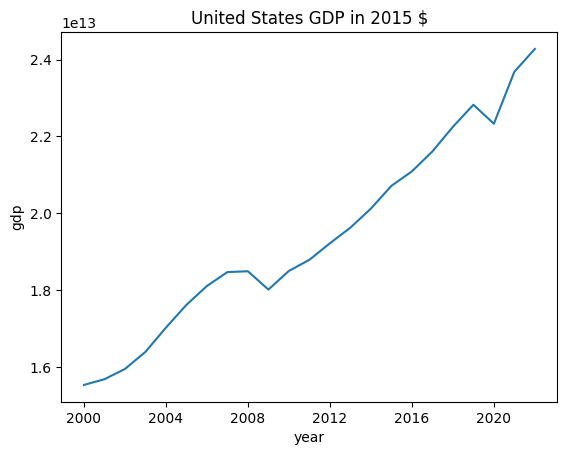

In [6]:
plot_one_country(df_combined, "United States", "gdp", ["usd"], "United States GDP in 2015 $")

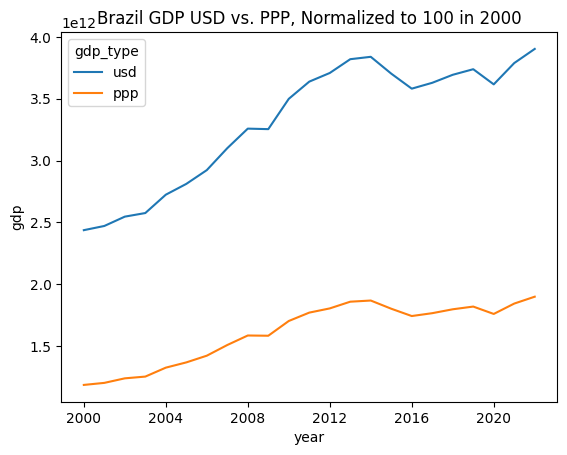

In [7]:
plot_one_country(df_combined, "Brazil", "gdp", ["usd", "ppp"], 
                 "Brazil GDP USD vs. PPP, Normalized to 100 in 2000")

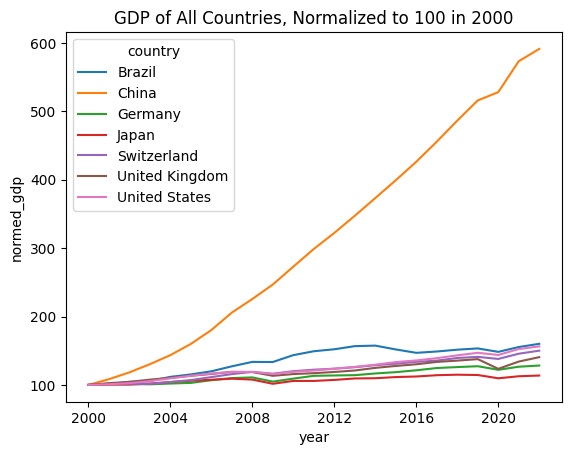

In [10]:
plot_all_countries(df_combined, "normed_gdp", "usd", "GDP of All Countries, Normalized to 100 in 2000")

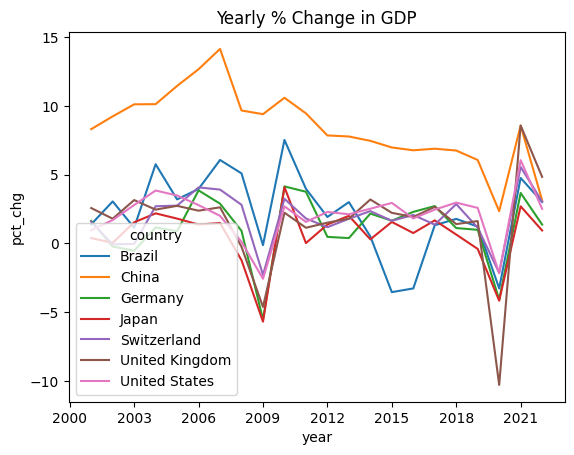

In [13]:
plot_all_countries(df_combined, "pct_chg", "usd", "Yearly % Change in GDP")

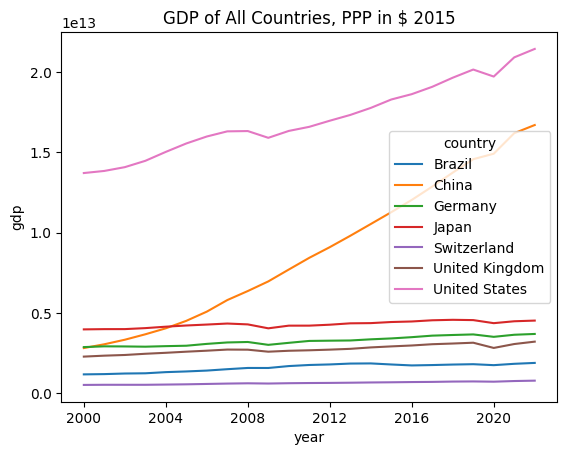

In [14]:
plot_all_countries(df_combined, "gdp", "ppp", "GDP of All Countries, PPP in $ 2015")

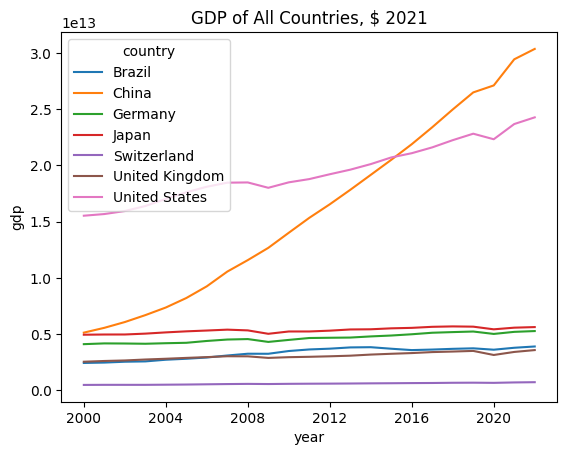

In [15]:
plot_all_countries(df_combined, "gdp", "usd", "GDP of All Countries, $ 2021")